#### Overview

##### Avellaneda & Stoikov (2008) is the foundational paper for rigorous market making theory. It formulates the market maker's problem as a stochastic optimal control problem: the dealer continuously posts bid and ask quotes to maximise terminal wealth while managing the risk of holding an undesirable inventory position. The result is an elegant closed-form solution that every serious quant in market microstructure needs to understand.

### The Setup

#### State Variables
* $S_t$ — mid-price of the asset, modelled as arithmetic Brownian motion: 
  $$dS_t = \sigma \, dW_t$$
* $q_t \in \mathbb{Z}$ — the market maker's inventory (shares held, positive = long, negative = short)
* $x_t$ — cash (wealth excluding the position value)

**Total wealth:** 
$$W_t = x_t + q_t S_t$$


### Control Variables
The dealer controls the spreads around the mid-price: 
$$\delta_t^a = S_t^a - S_t \quad \text{(ask spread)}$$
$$\delta_t^b = S_t - S_t^b \quad \text{(bid spread)}$$

### Order Arrival Model
Limit orders are filled by incoming market orders modelled as Poisson processes. The arrival intensity of buy (hitting the ask) and sell (hitting the bid) market orders is:
$$\lambda^a(\delta^a) = A e^{-k\delta^a}, \quad \lambda^b(\delta^b) = A e^{-k\delta^b}$$

where:
* $A > 0$ — baseline arrival rate
* $k > 0$ — sensitivity of arrival intensity to the spread (empirically estimated from order book data)

This captures the trade-off: tighter spreads attract more order flow but reduce per-trade profit.

### The Optimisation Problem
The dealer solves a finite-horizon utility maximisation:
$$\max_{\delta^a, \delta^b} \mathbb{E} \left[ -e^{-\gamma W_T} \right]$$

subject to the inventory and wealth dynamics, where $\gamma > 0$ is the absolute risk aversion parameter.

### The HJB Equation
Define the value function $u(t, x, q, S)$. By the dynamic programming principle, it satisfies the Hamilton-Jacobi-Bellman (HJB) PDE:
$$\frac{\partial u}{\partial t} + \frac{\sigma^2}{2} \frac{\partial^2 u}{\partial S^2} + \max_{\delta^a} \left[ \lambda^a(\delta^a) \left( u(t, x + S + \delta^a, q - 1, S) - u \right) \right] + \max_{\delta^b} \left[ \lambda^b(\delta^b) \left( u(t, x - S + \delta^b, q + 1, S) - u \right) \right] = 0$$

**Terminal condition:** 
$$u(T, x, q, S) = -e^{-\gamma(x + qS)}$$

### The Solution: Closed-Form Quote Schedules

#### Ansatz
Conjecture the form: 
$$u(t, x, q, S) = -e^{-\gamma(x + qS + \theta(t, q))}$$

Substituting into the HJB and solving the resulting ODE system yields the **reservation price** (the market maker's subjective mid-price adjusted for inventory risk):
$$r(t, q) = S - q\gamma\sigma^2(T - t)$$

The term $-q\gamma\sigma^2(T - t)$ is the inventory penalty: a long position ($q > 0$) causes the dealer to shade their quotes downward to offload inventory.

#### Optimal Spreads
The optimal bid-ask half-spread is:
$$\delta^* = \frac{1}{2} \left( \frac{\gamma\sigma^2(T-t)}{1 + \frac{\gamma}{k}} \right) + \frac{1}{\gamma} \ln \left( 1 + \frac{\gamma}{k} \right)$$

The total optimal spread posted around the reservation price is:
$$\text{Spread} = \delta^a + \delta^b = \gamma\sigma^2(T-t) + \frac{2}{\gamma} \ln \left( 1 + \frac{\gamma}{k} \right)$$

Notably, the spread has two components:
1. $\gamma\sigma^2(T-t)$ — adverse selection / inventory risk component (shrinks as $T$ approaches)
2. $\frac{2}{\gamma} \ln \left( 1 + \frac{\gamma}{k} \right)$ — intrinsic spread (independent of time, driven by market depth $k$)


In [2]:
import numpy as np
from dataclasses import dataclass
 
@dataclass
class AvellanedaStoikov:
    """
    Optimal market making quotes under the Avellaneda-Stoikov (2008) model.
    """
    sigma: float # Mid-price volatility (per unit time)
    gamma: float # Market maker's absolute risk aversion
    k: float # Order arrival decay (sensitivity to spread)
    T: float # Total horizon (seconds, minutes, or days)
 
    def reservation_price(self, S: float, q: int, t: float) -> float:
        """Inventory-adjusted mid price (dealer's fair value)."""
        time_remaining = self.T - t
        return S - q * self.gamma * self.sigma**2 * time_remaining
 
    def optimal_spread(self, t: float) -> float:
        """Total optimal bid-ask spread."""
        time_remaining = self.T - t
        inventory_component = self.gamma * self.sigma**2 * time_remaining
        intrinsic_component = (2 / self.gamma) * np.log(1 + self.gamma / self.k)
        return inventory_component + intrinsic_component
 
    def quotes(self, S: float, q: int, t: float) -> tuple[float, float]:
        """Return (bid_price, ask_price) optimal quotes."""
        r = self.reservation_price(S, q, t)
        half_spread = self.optimal_spread(t) / 2
        return r - half_spread, r + half_spread

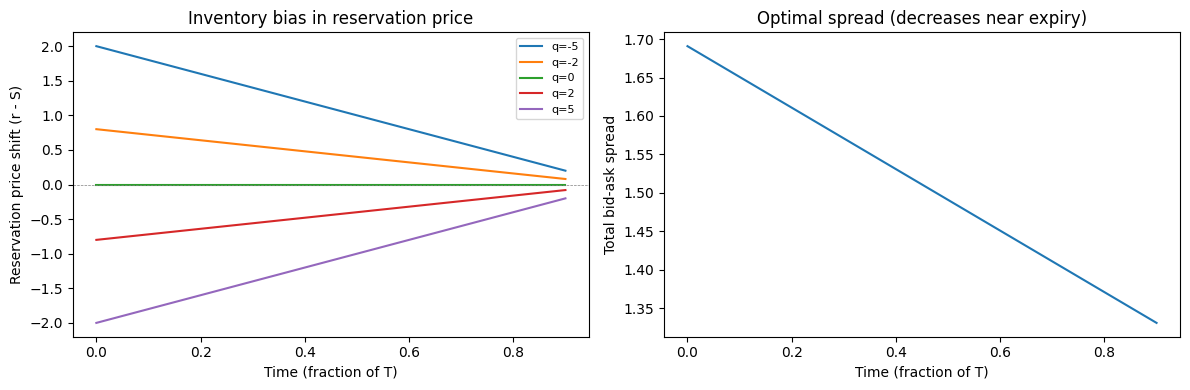

In [3]:
import matplotlib.pyplot as plt
 
mm = AvellanedaStoikov(sigma=2.0, gamma=0.1, k=1.5, T=1.0)
 
inventories = [-5, -2, 0, 2, 5]
times = np.linspace(0, 0.9, 100)
S = 100.0
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
# Reservation price shift vs inventory
for q in inventories:
    r_prices = [mm.reservation_price(S, q, t) for t in times]
    ax1.plot(times, [r - S for r in r_prices], label=f"q={q}")
ax1.set_xlabel("Time (fraction of T)")
ax1.set_ylabel("Reservation price shift (r - S)")
ax1.set_title("Inventory bias in reservation price")
ax1.legend(fontsize=8)
ax1.axhline(0, color="gray", lw=0.5, ls="--")
 
# Optimal spread over time
spreads = [mm.optimal_spread(t) for t in times]
ax2.plot(times, spreads)
ax2.set_xlabel("Time (fraction of T)")
ax2.set_ylabel("Total bid-ask spread")
ax2.set_title("Optimal spread (decreases near expiry)")
plt.tight_layout()

##### At t=0, q=0 (neutral inventory):

In [19]:
# S=100
bid, ask = mm.quotes(S=100.0, q=0, t=0.0)
print(f"Reservation price: {mm.reservation_price(100.0, 0, 0.0):.4f}")
print(f"Optimal spread:    {mm.optimal_spread(1.0):.4f}")
print(f"Bid: {bid:.4f}  |  Ask: {ask:.4f}")

Reservation price: 100.0000
Optimal spread:    1.2908
Bid: 99.1546  |  Ask: 100.8454


### Key Insights

1. **Inventory skews the fair value**
   When the dealer is long ($q > 0$), their reservation price is below mid. They want to sell — so they shade their ask downward, and their bid downward. This creates asymmetric quotes that correct the inventory imbalance without market impact.

2. **Spread widens with volatility**
   Higher $\sigma \rightarrow$ wider spread. This is consistent with empirical observation: dealers widen quotes in volatile markets to compensate for the increased adverse-selection risk.

3. **Risk aversion controls spread scaling**
   * $\gamma \rightarrow 0$: the dealer is risk-neutral and only posts the intrinsic spread $\frac{2}{k}$.
   * $\gamma \rightarrow \infty$: the dealer is extremely risk-averse, quoting extremely wide to avoid any inventory accumulation.

4. **Spread narrows near horizon**
   As $t \rightarrow T$, the $\gamma\sigma^2(T - t)$ component vanishes. Near end-of-day, the inventory risk matters less (there is no time left to get hurt), so the dealer tightens quotes.

### Limitations and Extensions


| Limitation | Extension |
| :--- | :--- |
| Symmetric Poisson arrival (same $\lambda$ for buy/sell) | Guéant, Lehalle & Fernandez-Tapia (2013) — general intensity functions |
| No adverse selection (informed traders) | Cartea, Jaimungal & Penalva (2015) — incorporating toxic flow |
| Continuous quoting (no discrete tick sizes) | Fodra & Pham (2015) — discrete LOB models |
| Single asset | Guéant (2017) — multi-asset market making |
| No queue dynamics | Laruelle, Lehalle & Pagès (2011) — queue-reactive models |

Avellaneda-Stoikov remains the canonical starting point. Every serious HFT market making system either uses this model directly or can trace its intellectual lineage back to it.

### Implementation Notes

In practice, the parameters require careful estimation:
* $\sigma$: estimate from realized variance over a short rolling window (e.g., 5-minute bars).
* $k$: estimate from LOB data by regressing $\log(\text{fill rate})$ on spread-to-mid distance.
* $\gamma$: often calibrated via Sharpe ratio targeting or set by risk limits on intra-day inventory exposure.
* $T$: usually the trading session length (6.5 hours for US equities) or a rolling window.


### Avellaneda & Stoikov (A&S) Research Paper Link:
  https://people.orie.cornell.edu/sfs33/LimitOrderBook.pdf